# Importando Dados

In [2]:
!pip install pydytuesday -q
import pydytuesday
import pandas as pd

# Download files from the week, which you can then read in locally
pydytuesday.get_date('2026-06-16')

# Option 2: Read directly from GitHub and assign to an object

england_wales_names = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-06-16/england_wales_names.csv')
ni_names = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-06-16/ni_names.csv')
scotland_names = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-06-16/scotland_names.csv')

Trying to fetch README from: https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2026/2026-06-16/readme.md
Successfully fetched README from: https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2026/2026-06-16/readme.md
Successfully saved chart.png to /content/chart.png
Successfully saved cleaning.R to /content/cleaning.R
Successfully saved england_wales_names.csv to /content/england_wales_names.csv
Successfully saved england_wales_names.md to /content/england_wales_names.md
Successfully saved intro.md to /content/intro.md
Successfully saved meta.yaml to /content/meta.yaml
Successfully saved ni_names.csv to /content/ni_names.csv
Successfully saved ni_names.md to /content/ni_names.md
Successfully saved scotland_names.csv to /content/scotland_names.csv
Successfully saved scotland_names.md to /content/scotland_names.md


# Concatenação

In [3]:
scotland_names.info()

<class 'pandas.DataFrame'>
RangeIndex: 74331 entries, 0 to 74330
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    74331 non-null  int64
 1   Sex     74331 non-null  str  
 2   Name    74331 non-null  str  
 3   Number  74331 non-null  int64
 4   Rank    74331 non-null  int64
dtypes: int64(3), str(2)
memory usage: 3.5 MB


In [4]:
scotland_names.head()

,Year,Sex,Name,Number,Rank
0,1974,Boy,Aaron,17,139
1,1974,Boy,Abdul,5,248
2,1974,Boy,Adam,75,78
3,1974,Boy,Adrian,46,92
4,1974,Boy,Aftab,3,297


In [39]:
df_1 = scotland_names.copy()
df_2 = england_wales_names.copy()
df_3 = ni_names.copy()

df_1['Country'] = "Escócia"
df_2['Country'] = "Inglaterra e País de Gales"
df_3['Country'] = "Irlanda do Norte"

df = pd.concat([df_1, df_2, df_3])
df.sample(10)

,Year,Sex,Name,Number,Rank,Country
156099,2024,Boy,Tristan,189.0,253.0,Inglaterra e País de Gales
166762,1998,Girl,Aleighsha,3.0,3848.0,Inglaterra e País de Gales
20120,1993,Boy,Greig,53.0,103.0,Escócia
11439,1999,Boy,Alden,5.0,2097.0,Inglaterra e País de Gales
129547,2020,Boy,Panashe,4.0,3848.0,Inglaterra e País de Gales
178028,2000,Girl,Elizabeta,3.0,3912.0,Inglaterra e País de Gales
97792,2015,Boy,Kodie,15.0,1586.0,Inglaterra e País de Gales
89872,2012,Girl,Katrina,NaN,NaN,Irlanda do Norte
141477,2022,Boy,Muhaymin,5.0,3450.0,Inglaterra e País de Gales
54528,2008,Boy,Hari,67.0,514.0,Inglaterra e País de Gales


In [40]:
df['Year'].value_counts()

# Pelo range dos dados, o ângulo da análise deve ser algo como o legado dos Beatles em nomes de bebês, ao invés do Boom da Beatlemania (1964-66).
# Pontos interessantes a investigar:
# 1980: assassinato de John Lennon
# 2001: morte de George Harrison
# 2023: "Now and Then" (última "nova" música dos Beatles, usando IA)

Year
2024    20422
2012    19932
2023    19873
2016    19839
2017    19763
2011    19675
2015    19628
2013    19614
2022    19586
2021    19575
2018    19565
2014    19510
2010    19400
2019    19334
2020    19178
2009    19078
2008    19011
2007    18349
2006    17607
2005    16916
2004    16417
2003    15853
2002    15110
2001    14751
2000    14577
1999    14321
1998    14288
1997    14195
1996     9960
2025     6146
1992     1258
1991     1257
1995     1231
1994     1230
1993     1211
1990     1169
1988     1136
1987     1107
1989     1088
1986     1065
1985     1033
1980     1025
1984     1019
1981     1017
1982     1002
1983      997
1979      989
1978      959
1976      958
1975      957
1977      955
1974      938
Name: count, dtype: int64

# Análise

In [25]:
# Nomes dos integrantes:

df_beatles = df.copy()
df_beatles = df_beatles[df_beatles['Name'].isin([
    "Paul",
    "Ringo",
    "John",
    "George"
])]

df_beatles["Name"].value_counts()

Name
George    118
John      111
Paul      110
Ringo       1
Name: count, dtype: int64

In [17]:
# Nome derivados de músicas:

df_musicas = df.copy()
df_musicas = df_musicas[df_musicas['Name'].isin([
    "Jude", # Hey Jude, 1968
    "Eleanor", # Eleanor Rigby, 1966
    "Lucy", # Lucy in the Sky With Diamonds, 1967
    "Michelle", # Michelle, 1965
    "Prudence", # Dear Prudence, 1968
    "Rita", # Lovely Rita, 1967
    "Julia", # Julia, 1968
    "Martha", # Martha My Dear, 1968
    "Anna" # Anna (Go to Him), 1963
])]

df_musicas["Name"].value_counts()

Name
Jude        143
Anna        110
Eleanor     110
Julia       110
Lucy        110
Martha      109
Michelle    109
Rita         67
Prudence     29
Name: count, dtype: int64

In [19]:
# Nomes miscelânia:

df_misc = df.copy()
df_misc = df_misc[df_misc['Name'].isin([
    "Yoko",
    "Linda",
])]

df_misc["Name"].value_counts()

Name
Linda    85
Yoko      1
Name: count, dtype: int64

# Gráfico

In [29]:
pd.set_option('display.max_rows', 200)

In [31]:
df_g.sort_values("Year")

,Name,Year,Total
0,George,1974,302.0
52,John,1974,1528.0
104,Paul,1974,1260.0
53,John,1975,1481.0
105,Paul,1975,1207.0
1,George,1975,296.0
2,George,1976,259.0
54,John,1976,1374.0
106,Paul,1976,1146.0
107,Paul,1977,1230.0


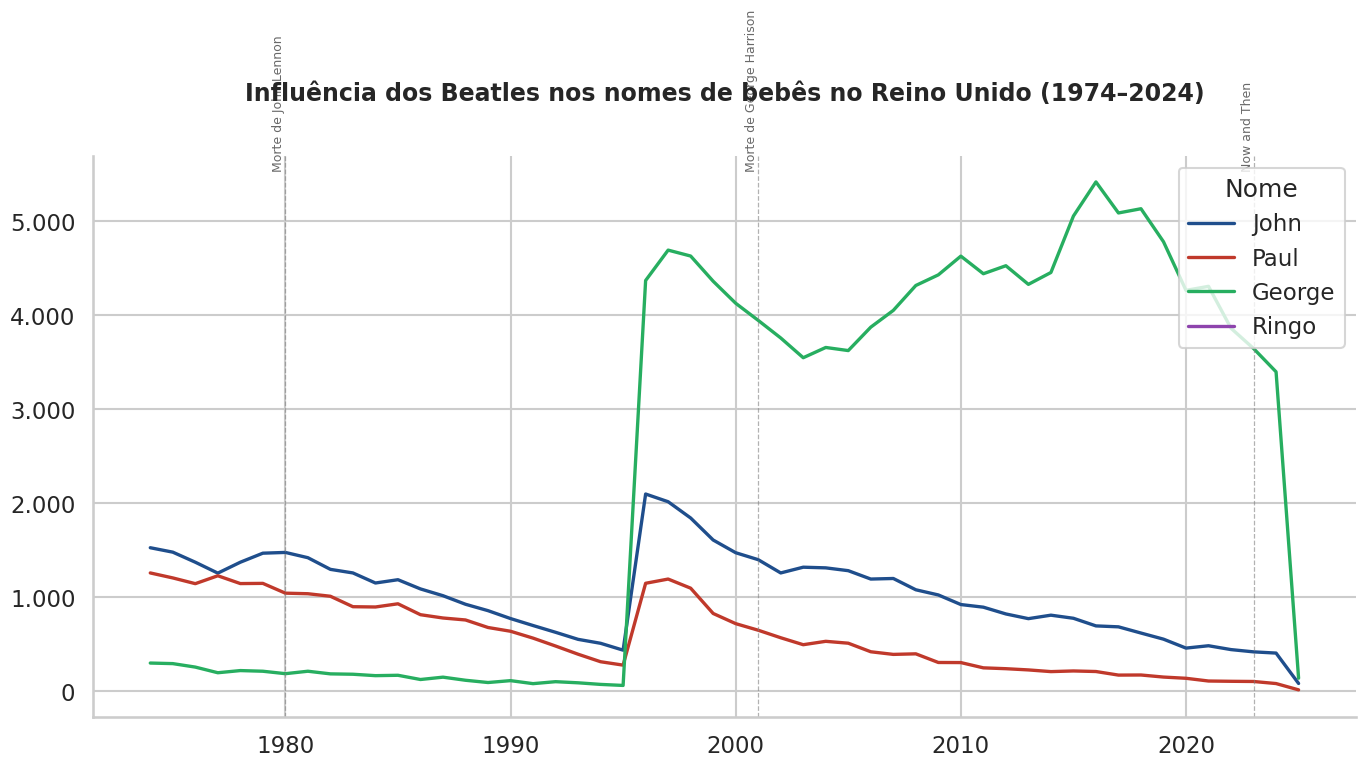

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

NOMES_FILTRO = ["John", "Paul", "George", "Ringo"]

PALETA = {
    "John":    "#1f4e8c",
    "Paul":    "#c0392b",
    "George":  "#27ae60",
    "Ringo":   "#8e44ad"
}

EVENTOS = [
    (1980, "Morte de John Lennon"),
    (2001, "Morte de George Harrison"),
    (2023, "Now and Then"),
]

# Agrupamento
df_g = (
    df_beatles
    .groupby(["Name", "Year"], as_index=False)["Number"]
    .sum()
    .rename(columns={"Number": "Total"})
)

# Estilo
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(14, 8))

# Linhas
for nome in NOMES_FILTRO:

    sub = (
        df_g[df_g["Name"] == nome]
        .sort_values("Year")
    )

    if sub.empty:
        continue

    sns.lineplot(
        data=sub,
        x="Year",
        y="Total",
        label=nome,
        color=PALETA.get(nome),
        linewidth=2.4,
        ax=ax,
    )

# Eventos
ymax = df_g["Total"].max()

for ano, label in EVENTOS:

    if ano < df_g["Year"].min() or ano > df_g["Year"].max():
        continue

    ax.axvline(
        ano,
        color="gray",
        linestyle="--",
        linewidth=0.9,
        alpha=0.6,
    )

    ax.text(
        ano,
        ymax * 1.02,
        label,
        rotation=90,
        va="bottom",
        ha="right",
        fontsize=9,
        color="dimgray",
    )

# Formatação
ax.set_title(
    "Influência dos Beatles nos nomes de bebês no Reino Unido (1974–2024)",
    fontsize=17,
    weight="bold",
    pad=40,
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"{int(x):,}".replace(",", ".")
    )
)

ax.legend(
    title="Nome",
    loc="upper right",
    frameon=True,
)

sns.despine()

plt.tight_layout()
plt.show()

# plt.savefig("beatles_nomes_seaborn.png", dpi=200, bbox_inches="tight")

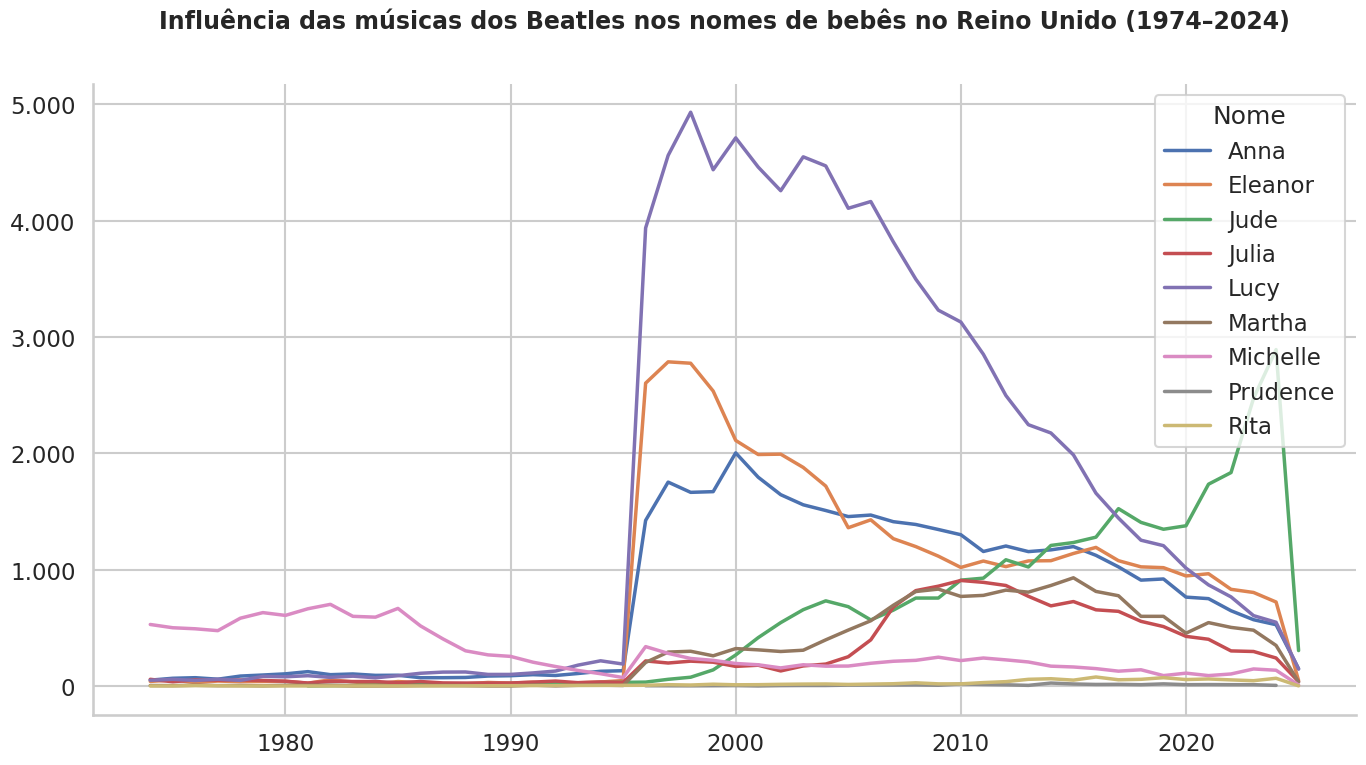

In [45]:
# Agrupamento
df_g = (
    df_musicas
    .groupby(["Name", "Year"], as_index=False)["Number"]
    .sum()
    .rename(columns={"Number": "Total"})
)

# Estilo
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(14, 8))

# Linhas
sns.lineplot(
    data=df_g,
    x="Year",
    y="Total",
    hue="Name",
    linewidth=2.5,
    ax=ax,
)

# Formatação
ax.set_title(
    "Influência das músicas dos Beatles nos nomes de bebês no Reino Unido (1974–2024)",
    fontsize=17,
    weight="bold",
    pad=40,
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"{int(x):,}".replace(",", ".")
    )
)

ax.legend(
    title="Nome",
    loc="upper right",
    frameon=True,
)

sns.despine()

plt.tight_layout()
plt.show()

# plt.savefig("beatles_nomes_seaborn.png", dpi=200, bbox_inches="tight")

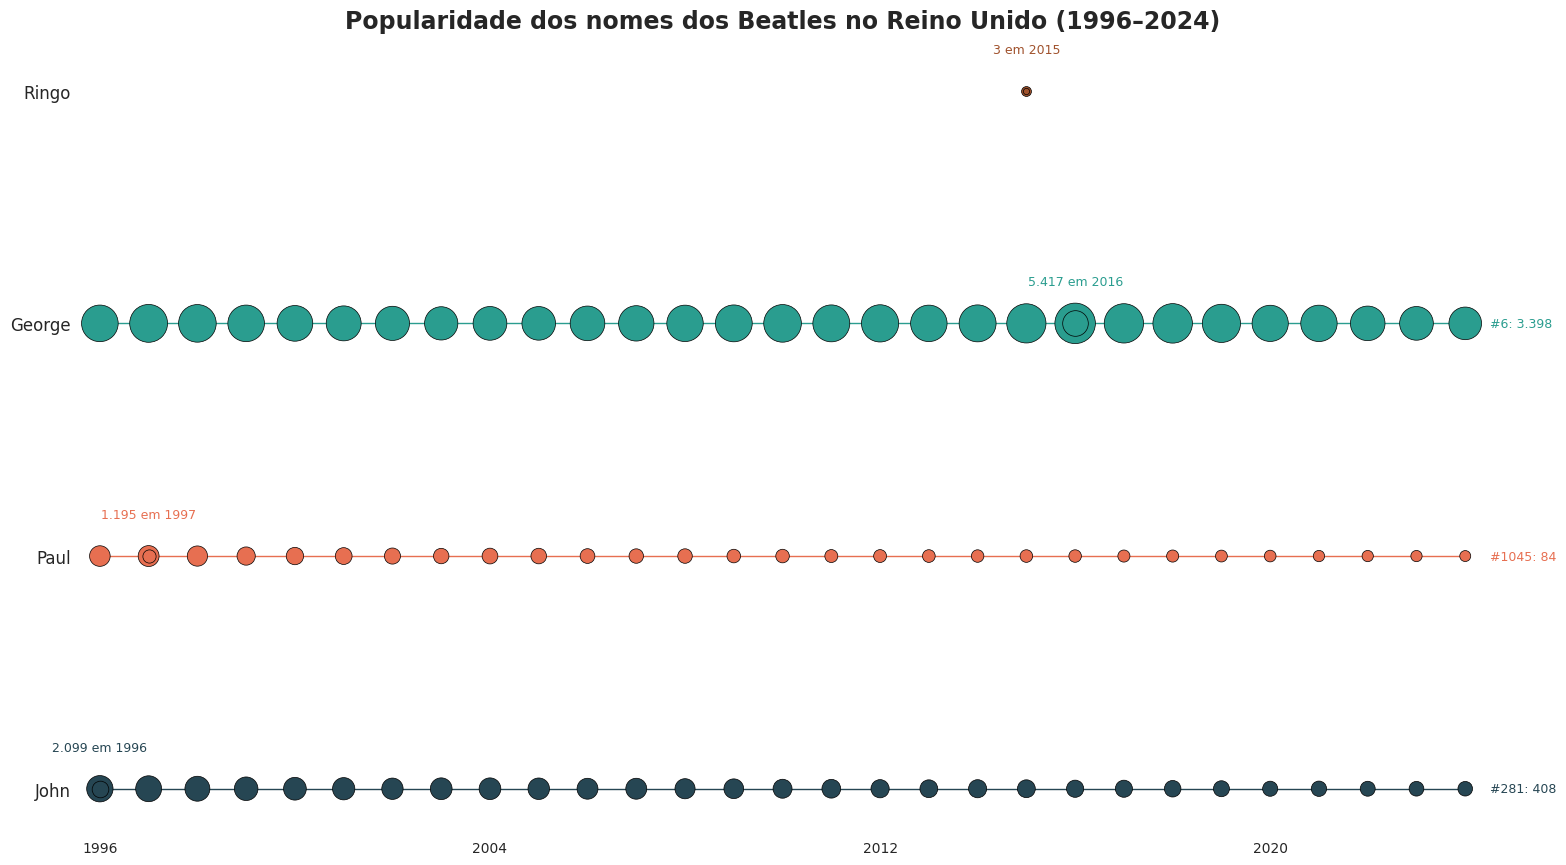

In [55]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import matplotlib.font_manager as fm
import urllib.request

# --- 1. Font Setup (Removed - using default fonts) ---

# Filter the data for the specified year range
df_filtered = df_beatles[
    (df_beatles['Year'] >= 1996) & (df_beatles['Year'] <= 2024)
].copy()

# Group data to get total number per name per year for plotting
df_g_plot = (
    df_filtered
    .groupby(["Name", "Year"], as_index=False)["Number"]
    .sum()
    .rename(columns={"Number": "Total"})
)

# --- 2. Define names and NEW palette ---
NOMES_FILTRO = ["John", "Paul", "George", "Ringo"]
PALETA = {
    "John":    "#264653", # Updated dark blue
    "Paul":    "#E76F51", # Updated red-orange
    "George":  "#2A9D8F", # Updated teal
    "Ringo":   "#A0522D"  # Updated Ringo's color to Sienna
}

# Prepare data for annotations
# 1. Max count year and total for each name within the filtered range
max_counts_info = df_g_plot.loc[df_g_plot.groupby('Name')['Total'].idxmax()]
max_counts_dict = max_counts_info.set_index('Name')[['Year', 'Total']].to_dict('index')

# 2. 2024 ranks for each name (overall rank, not sex-specific)
# Get total numbers per name per year from the original `df` for accurate ranking
df_total_per_name_year = df.groupby(['Year', 'Name'], as_index=False)['Number'].sum()

# Calculate overall rank based on total numbers for each year
df_total_per_name_year['Overall_Rank'] = df_total_per_name_year.groupby('Year')['Number'].rank(method='min', ascending=False)

# Filter for 2024 ranks for the Beatles names and format as #X
beatles_2024_ranks_dict = df_total_per_name_year[
    (df_total_per_name_year['Year'] == 2024) &
    (df_total_per_name_year['Name'].isin(NOMES_FILTRO))
].set_index('Name')['Overall_Rank'].apply(lambda x: f"#{int(x)}").to_dict()

# Set up the plot
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(16, 9)) # Wider for horizontal lollipop

# Iterate through names to create lollipop plot
y_pos_base = 0 # Starting y-position for the first name
y_spacing = 1 # Spacing between names for each name's line

# Determine max total for scaling circle sizes consistently
max_total_for_scaling = df_g_plot['Total'].max() if not df_g_plot.empty else 1

for i, name in enumerate(NOMES_FILTRO):
    subset = df_g_plot[df_g_plot['Name'] == name].sort_values('Year')

    if subset.empty:
        continue # Skip if no data for the name in the filtered range

    current_color = PALETA.get(name, 'gray')
    y_current = y_pos_base + i * y_spacing

    # Plot horizontal line for each name
    ax.plot(
        subset['Year'],
        [y_current] * len(subset),
        color=current_color,
        linestyle='-',
        linewidth=1,
        alpha=1, # Explicitly set alpha to 1
        zorder=1
    )

    # Plot circles (points) with size based on 'Total'
    # Scale `Total` linearly to a reasonable visible range
    circle_sizes = (subset['Total'] / max_total_for_scaling) * 800 + 50 # Scale from 50 to 850

    ax.scatter(
        subset['Year'],
        [y_current] * len(subset),
        s=circle_sizes,
        color=current_color,
        alpha=1, # Explicitly set alpha to 1
        edgecolors='black',
        linewidth=0.5,
        zorder=2
    )

    # Add annotation for max count year
    max_info = max_counts_dict.get(name)
    if max_info:
        max_year = max_info['Year']
        max_total = max_info['Total']

        # Plot a smaller inner circle at the max point (bullseye effect)
        ax.scatter(
            max_year,
            y_current,
            s=((max_total / max_total_for_scaling) * 800 + 50) * 0.4, # smaller inner circle
            color=current_color, # Changed from 'white' to current_color
            edgecolors='black',
            linewidth=0.5,
            zorder=3
        )
        # Annotation for total count at max year without rounded box
        ax.text(
            max_year,
            y_current + 0.15 * y_spacing, # slightly above the point
            f"{int(max_total):,} em {int(max_year)}".replace(",", "."), # Updated format
            fontsize=9,
            ha='center',
            va='bottom',
            color=current_color, # Changed from 'white' to current_color
            zorder=4
        )

    # Add annotation for 2024 rank on the last circle (year 2024)
    rank_2024_str = beatles_2024_ranks_dict.get(name)
    if rank_2024_str:
        x_2024 = 2024 # X coordinate for year 2024
        # Get the actual count for 2024
        count_2024_df = df_total_per_name_year[(df_total_per_name_year['Year'] == 2024) & (df_total_per_name_year['Name'] == name)]
        count_2024 = count_2024_df['Number'].iloc[0] if not count_2024_df.empty else 0

        # Annotation for 2024 rank without rounded box
        ax.text(
            x_2024 + 0.5, # Slightly to the right to avoid overlap
            y_current,
            f"{rank_2024_str}: {int(count_2024):,}".replace(",", "."), # Updated format
            fontsize=9,
            ha='left', # Align to left
            va='center', # Center vertically
            color=current_color, # Changed from 'white' to current_color
            zorder=4
        )

# Customizing the y-axis for names
ax.set_yticks([y_pos_base + i * y_spacing for i in range(len(NOMES_FILTRO))])
ax.set_yticklabels(NOMES_FILTRO)

# Title and labels
ax.set_title(
    "Popularidade dos nomes dos Beatles no Reino Unido (1996–2024)",
    fontsize=17,
    weight="bold",
    pad=20
)
ax.set_xlabel("")
ax.set_ylabel("")

# X-axis ticks for better readability (every 8 years)
ax.set_xticks(range(1996, 2025, 8))
ax.tick_params(axis='x', rotation=0, labelsize=10) # Changed rotation to 0
ax.tick_params(axis='y', labelsize=12, length=0) # Remove y-axis tick marks

# Limit x-axis to the filtered range
ax.set_xlim(1995.5, 2024.5)

# --- 3. Minimalist Design Adjustments ---
sns.despine(left=True, bottom=True, right=True, top=True) # Remove all four spines (axis lines)

# Remove x-axis grid lines
ax.xaxis.grid(False)
ax.yaxis.grid(False) # No horizontal grid lines needed as lines are specific to names

plt.tight_layout()
plt.show()

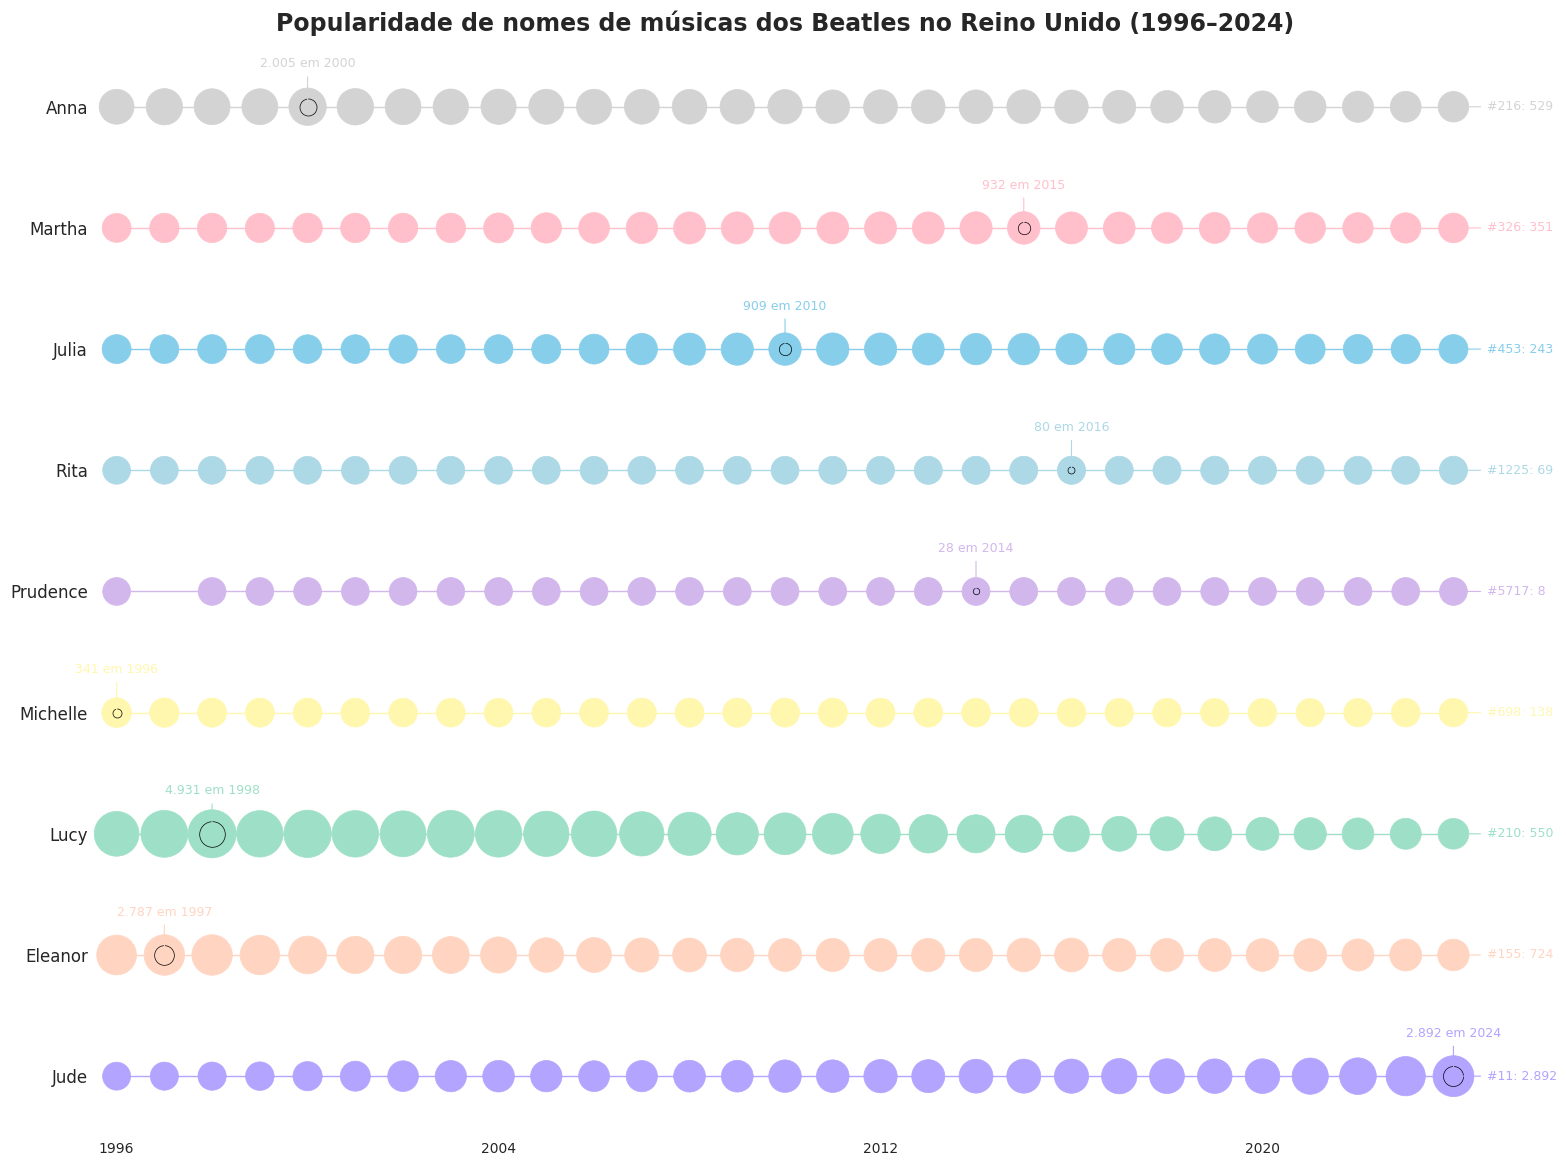

In [62]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd

# --- 1. Font Setup (Removed - using default fonts) ---

# Filter the data for the specified year range (using df_musicas)
df_filtered_musicas = df_musicas[
    (df_musicas['Year'] >= 1996) & (df_musicas['Year'] <= 2024)
].copy()

# Group data to get total number per name per year for plotting
df_g_plot_musicas = (
    df_filtered_musicas
    .groupby(["Name", "Year"], as_index=False)["Number"]
    .sum()
    .rename(columns={"Number": "Total"})
)

# --- 2. Define names and NEW palette for music names (pastel tones) ---
NOMES_FILTRO_MUSICAS = [
    "Jude", "Eleanor", "Lucy", "Michelle",
    "Prudence", "Rita", "Julia", "Martha", "Anna"
]
PALETA_MUSICAS = {
    "Jude":      "#B2A4FF", # Pastel Purple
    "Eleanor":   "#FFD5C2", # Pastel Salmon
    "Lucy":      "#9EE0C7", # Pastel Green
    "Michelle":  "#FFF7AE", # Pastel Yellow
    "Prudence":  "#D2B7ED", # Pastel Lavender
    "Rita":      "#ADD8E6", # Light Blue
    "Julia":     "#87CEEB", # Sky Blue
    "Martha":    "#FFC0CB", # Pink
    "Anna":      "#D3D3D3"  # Light Gray
}

# Prepare data for annotations
# 1. Max count year and total for each name within the filtered range
max_counts_info_musicas = df_g_plot_musicas.loc[df_g_plot_musicas.groupby('Name')['Total'].idxmax()]
max_counts_dict_musicas = max_counts_info_musicas.set_index('Name')[['Year', 'Total']].to_dict('index')

# 2. 2024 ranks for each name (overall rank, not sex-specific)
# Using df_total_per_name_year which was already calculated globally
# Filter for 2024 ranks for the music names and format as #X
musicas_2024_ranks_dict = df_total_per_name_year[
    (df_total_per_name_year['Year'] == 2024) &
    (df_total_per_name_year['Name'].isin(NOMES_FILTRO_MUSICAS))
].set_index('Name')['Overall_Rank'].apply(lambda x: f"#{int(x)}").to_dict()

# Set up the plot
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(16, 12)) # Wider and taller for more names

# Iterate through names to create lollipop plot
y_pos_base = 0 # Starting y-position for the first name
y_spacing = 1 # Spacing between names for each name's line

# Determine max total for scaling circle sizes consistently
max_total_for_scaling_musicas = df_g_plot_musicas['Total'].max() if not df_g_plot_musicas.empty else 1

for i, name in enumerate(NOMES_FILTRO_MUSICAS):
    subset = df_g_plot_musicas[df_g_plot_musicas['Name'] == name].sort_values('Year')

    if subset.empty:
        continue # Skip if no data for the name in the filtered range

    current_color = PALETA_MUSICAS.get(name, 'gray')
    y_current = y_pos_base + i * y_spacing

    # Plot horizontal line for each name
    ax.plot(
        subset['Year'],
        [y_current] * len(subset),
        color=current_color,
        linestyle='-',
        linewidth=1,
        alpha=1, # Explicitly set alpha to 1
        zorder=1
    )

    # Plot circles (points) with size based on 'Total'
    # Scale `Total` linearly to a reasonable visible range
    circle_sizes = (subset['Total'] / max_total_for_scaling_musicas) * 800 + 400 # Scale from 50 to 850

    ax.scatter(
        subset['Year'],
        [y_current] * len(subset),
        s=circle_sizes,
        color=current_color,
        alpha=1, # Explicitly set alpha to 1
        edgecolors=current_color, # Changed to match fill color
        linewidth=0.5,
        zorder=2
    )

    # Add annotation for max count year
    max_info = max_counts_dict_musicas.get(name)
    if max_info:
        max_year = max_info['Year']
        max_total = max_info['Total']

        # Plot a smaller inner circle at the max point (bullseye effect)
        ax.scatter(
            max_year,
            y_current,
            s=((max_total / max_total_for_scaling_musicas) * 800 + 50) * 0.4, # smaller inner circle
            color=current_color,
            edgecolors='black',
            linewidth=0.5,
            zorder=3
        )
        # Annotation for total count at max year with leader line
        ax.annotate(
            f"{int(max_total):,} em {int(max_year)}".replace(",", "."),
            xy=(max_year, y_current), # Point to the center of the circle
            xytext=(max_year, y_current + 0.3 * y_spacing), # Position the text above the point
            fontsize=9,
            ha='center',
            va='bottom',
            color=current_color,
            arrowprops=dict(arrowstyle='-', color=current_color, lw=0.8, connectionstyle='arc3,rad=0'), # Straight leader line
            zorder=4
        )

    # Add annotation for 2024 rank on the last circle (year 2024)
    rank_2024_str = musicas_2024_ranks_dict.get(name)
    if rank_2024_str:
        x_2024 = 2024 # X coordinate for year 2024
        # Get the actual count for 2024
        count_2024_df = df_total_per_name_year[(df_total_per_name_year['Year'] == 2024) & (df_total_per_name_year['Name'] == name)]
        count_2024 = count_2024_df['Number'].iloc[0] if not count_2024_df.empty else 0

        # Annotation for 2024 rank with leader line
        ax.annotate(
            f"{rank_2024_str}: {int(count_2024):,}".replace(",", "."),
            xy=(x_2024, y_current), # Point to the center of the circle
            xytext=(x_2024 + 0.7, y_current), # Position the text to the right
            fontsize=9,
            ha='left', # Align to left
            va='center', # Center vertically
            color=current_color,
            arrowprops=dict(arrowstyle='-', color=current_color, lw=0.8, connectionstyle='arc3,rad=0'), # Straight leader line
            zorder=4
        )

# Customizing the y-axis for names
ax.set_yticks([y_pos_base + i * y_spacing for i in range(len(NOMES_FILTRO_MUSICAS))])
ax.set_yticklabels(NOMES_FILTRO_MUSICAS)

# Title and labels
ax.set_title(
    "Popularidade de nomes de músicas dos Beatles no Reino Unido (1996–2024)",
    fontsize=17,
    weight="bold",
    pad=20
)
ax.set_xlabel("")
ax.set_ylabel("")

# X-axis ticks for better readability (every 8 years)
ax.set_xticks(range(1996, 2025, 8))
ax.tick_params(axis='x', rotation=0, labelsize=10) # Changed rotation to 0
ax.tick_params(axis='y', labelsize=12, length=0) # Remove y-axis tick marks

# Limit x-axis to the filtered range
ax.set_xlim(1995.5, 2024.5)

# --- 3. Minimalist Design Adjustments ---
sns.despine(left=True, bottom=True, right=True, top=True) # Remove all four spines (axis lines)

# Remove x-axis grid lines
ax.xaxis.grid(False)
ax.yaxis.grid(False) # No horizontal grid lines needed as lines are specific to names

plt.tight_layout()
plt.show()